# PROACT in pan-cancer CAF scATAC-seq data

This tutorial demonstrates PROACT in pan-cancer cancer-associated fibroblasts (CAFs). Tumor ATAC-seq fragments were processed with ArchR and converted to a Signac object at first. Original fragement files could be downloaded from [TCGA](https://gdc.cancer.gov/about-data/ publications/TCGA-ATAC-Seq-2024). The example focuses on Myo_CAF-specific chromatin accessibility and cooperative TF inference.

> **Reproducibility note:** The code-cell outputs shown in this notebook are preserved from the original analysis run. Local file paths reflect the original analysis.

## Load the preprocessed scATAC-seq dataset

In [7]:
library(Seurat)
library(Signac)
library(Matrix)
library(GenomicRanges)
pcancer <- readRDS("examples/pcancer_CAFs/PanCancer_Fibroblast_Signac_Complete.rds")
pcancer

An object of class Seurat 
261587 features across 6645 samples within 2 assays 
Active assay: ATAC (236668 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: RNA
 2 dimensional reductions calculated: lsi, umap

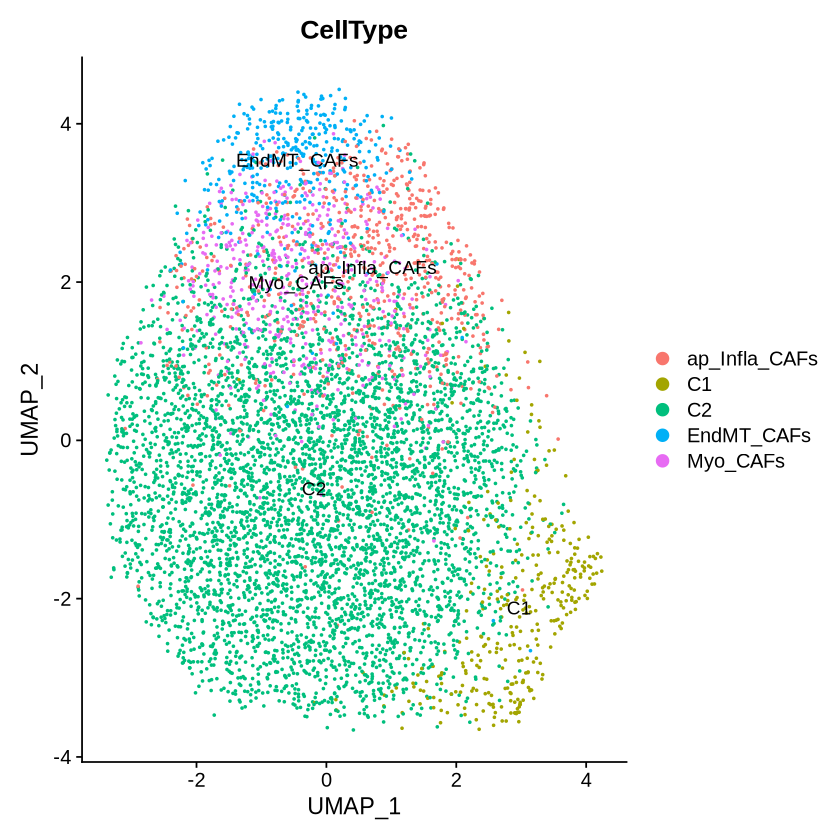

In [8]:
# UMAP
DimPlot(
  pcancer,
  reduction = "umap",
  group.by = "CellType",
  label = TRUE
)

## Identify subpopulation-specific accessible peaks

In [9]:
DefaultAssay(pcancer) <- 'ATAC'
Idents(pcancer) <- "CellType"
da_peaks <- FindMarkers(
        object = pcancer,
        only.pos = T,
        ident.1 = 'Myo_CAFs',
        ident.2 = 'ap_Infla_CAFs',
        test.use = 'wilcox',
        return.thresh = 0.01,
        min.pct = 0.1,
        logfc.threshold = 0.1
    )
da_peaks <- row.names(da_peaks[da_peaks$pct.1 > 0.2 & da_peaks$avg_log2FC > 0.25,])
length(da_peaks)

[1] 6503

## Prepare motif information

In [11]:
# ==============================================================================
# Motif preparation for PROACT
# ==============================================================================

library(motifmatchr)
library(TFBSTools)
library(JASPAR2024)
library(BSgenome.Hsapiens.UCSC.hg38)
library(GenomeInfoDb)

DefaultAssay(pcancer) <- "ATAC"
genome <- BSgenome.Hsapiens.UCSC.hg38
p_cutoff <- 1e-4
region_length <- 200

# 1. Load JASPAR2024 human CORE motifs
pfm <- getMatrixSet(
    x = "data/JASPAR2024.sqlite",
    opts = list(collection = "CORE", tax_group = "vertebrates",
                species = "Homo sapiens", all_versions = FALSE)
)

# 2. Add motif matrix and motif positions to the scATAC-seq object
peak_gr <- granges(pcancer)

motif_matrix <- CreateMotifMatrix(
    features = peak_gr, pwm = pfm, genome = genome,
    use.counts = FALSE, p.cutoff = p_cutoff
)

keep <- as.character(seqnames(peak_gr)) %in% seqlevels(genome)

motif_positions <- motifmatchr::matchMotifs(
    pwms = pfm, subject = peak_gr[keep], out = "positions",
    genome = genome, p.cutoff = p_cutoff
)

seqinfo(motif_positions) <- seqinfo(genome)[seqlevels(motif_positions)]

motif_obj <- CreateMotifObject(
    data = motif_matrix,
    positions = motif_positions,
    pwm = pfm
)

pcancer[["ATAC"]]@motifs <- motif_obj

# Optional: save the object with motif positions for grammar analysis
saveRDS(pcancer, file = "examples/pcancer_CAFs/pancancer_fibroblast_preprocessed_with_motifs.rds")


# 3. Generate the central 200-bp peak x motif matrix
peak_gr <- granges(pcancer)
peak_gr$peakID <- rownames(pcancer[["ATAC"]])

chrom_sizes <- seqlengths(genome)
keep_chr <- intersect(c(paste0("chr", 1:22), "chrX", "chrY"), names(chrom_sizes))
chrom_sizes <- chrom_sizes[keep_chr]

peak_seqinfo <- Seqinfo(seqnames = names(chrom_sizes), seqlengths = chrom_sizes)
seqlevels(peak_gr) <- seqlevels(peak_seqinfo)
seqinfo(peak_gr) <- peak_seqinfo

peak_gr <- trim(resize(peak_gr, width = region_length, fix = "center"))

motif_matrix_200 <- CreateMotifMatrix(
    features = peak_gr, pwm = pfm, genome = genome,
    use.counts = FALSE, p.cutoff = p_cutoff
)

peak_motif <- as.data.frame(motif_matrix_200)
peak_motif[] <- lapply(peak_motif, function(x) if (is.logical(x)) as.integer(x) else x)
peak_motif <- data.frame(peakID = peak_gr$peakID, peak_motif, check.names = FALSE)

# Remove chrY only after motif scanning
peak_chr <- sub("-.*$", "", peak_motif$peakID)
peak_motif <- peak_motif[peak_chr %in% c(paste0("chr", 1:22), "chrX"),,drop = FALSE]


# 4. Retain motifs included in the PROACT annotation
motif_anno_file <- system.file("extdata", "metadata.tsv", package = "PROACT")
motif_anno <- read.table(motif_anno_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

keep_motifs <- intersect(motif_anno$motif_id, colnames(peak_motif))
peak_motif <- peak_motif[, c("peakID", keep_motifs), drop = FALSE]

write.table(
    peak_motif,
    file = "examples/pcancer_CAFs/pancancer_fibroblast_peak_motif.central200bp.p1e-4.tsv",
    row.names = FALSE, col.names = TRUE, sep = "\t", quote = FALSE
)

Warning message in CreateMotifObject(data = motif_matrix, positions = motif_positions, :
“Non-unique motif names supplied, making unique”


## Identify overrepresented motifs as target TFs

In [12]:
# ==============================================================================
# Identification of target TFs
# ==============================================================================

# Calculate sequence features required by FindMotifs
pcancer <- RegionStats(object = pcancer, assay = "ATAC", genome = BSgenome.Hsapiens.UCSC.hg38)

# Identify enriched motifs for each cell type
set.seed(1)
enrich.motifs <- FindMotifs(object = pcancer, features = da_peaks)

# Remove redundant motifs using the default PROACT motif list
remove_motifs <- get("DEFAULT_REMOVE_MOTIFS", envir = asNamespace("PROACT"))
motif_anno <- motif_anno[!motif_anno$motif_id %in% remove_motifs, ]

# Select the top 100 significantly enriched motifs as target TFs
df <- enrich.motifs[enrich.motifs$motif %in% motif_anno$motif_id, ]
df <- df[df$p.adjust < 0.05, ]
df <- df[order(df$p.adjust, -df$fold.enrichment), ]
df <- head(df, 100)

tf <- motif_anno$tf_name[match(df$motif, motif_anno$motif_id)]
target_tfs <- unique(tf[!is.na(tf)])

Selecting background regions to match input sequence characteristics

Matching GC.percent distribution

Testing motif enrichment in 6503 regions



## Filter TFs by ArchR gene score

TF filtering based on gene score. Gene scores calculated by ArchR were used as a proxy for TF activity. TFs were retained if their gene score exceeded 0.7 in at least 20% of Myo_CAF cells.

In [13]:
# ==============================================================================
# Filter TFs by gene-score
# ==============================================================================

# Gene scores were calculated using ArchR and stored in the RNA assay.
DefaultAssay(pcancer) <- "RNA"

ident <- "Myo_CAFs"
min_pct <- 0.20
min_activity <- 0.70

# TFs included in the PROACT motif annotation
jaspar_tfs <- intersect(unique(motif_anno$tf_name), rownames(pcancer))

# Extract ArchR gene scores for Myo_CAFs
cells <- WhichCells(pcancer, idents = ident)
tf_activity <- GetAssayData(pcancer, layer = "data")[jaspar_tfs, cells, drop = FALSE]

# Retain TFs with sufficient activity across cells
pct_active <- rowMeans(tf_activity > min_activity)

expressed_tfs <- sort(names(which(pct_active >= min_pct)))

message(ident, ": ", length(expressed_tfs), " TFs retained.")

Myo_CAFs: 273 TFs retained.



## Run PROACT

In [14]:
# ==============================================================================
# Run PROACT
# ==============================================================================

library(PROACT)

# 1. Build the TF prior matrix
jaspar_tfs <- unique(motif_anno$tf_name)

prior_mat <- build_prior(
    jaspar_tfs,
    ppi_dir = "data/PPI_data/human"
)

# 2. Run PROACT 
# Prepare peak x TF matrix
peak_tf <- prepare_peak_tf_matrix(
    peak_motif_mat = peak_motif,
    da_peaks = da_peaks,
    filter_expr = TRUE,
    expr_tfs = expressed_tfs
)

# Infer cooperative TF pairs
result <- run_PROACT(
    peak_tf_matrix = peak_tf,
    prior_mat = prior_mat,
    target_tfs = target_tfs,
    ncores = 4
)

Loading PPI databases ...

Block1 pairs: 1870

Block2 pairs: 3626


Preparing Peak x TF matrix


After peak filtering: 6503 peaks

Removed 37 redundant motif columns

Using minimum motif count = 5

615 TFs retained

273 TFs retained after expression filtering

Final matrix: 6503 peaks x 273 TFs

273 TFs used for priority lasso

49 target TFs retained for modeling



  |                                                                      |   0%

SP1: 264 TFs as predictors
SP1:38:4:222




  |=                                                                     |   2%

EGR3: 269 TFs as predictors
EGR3:269




...

  |===================================================================   |  96%

ELF4: 259 TFs as predictors
ELF4:2:12:245




  |===================================================================== |  98%

ETV6: 259 TFs as predictors
ETV6:3:256




  |======================================================================| 100%



## Visualize the cooperative TF network

Anchor mode: 9 anchor TFs detected in network.



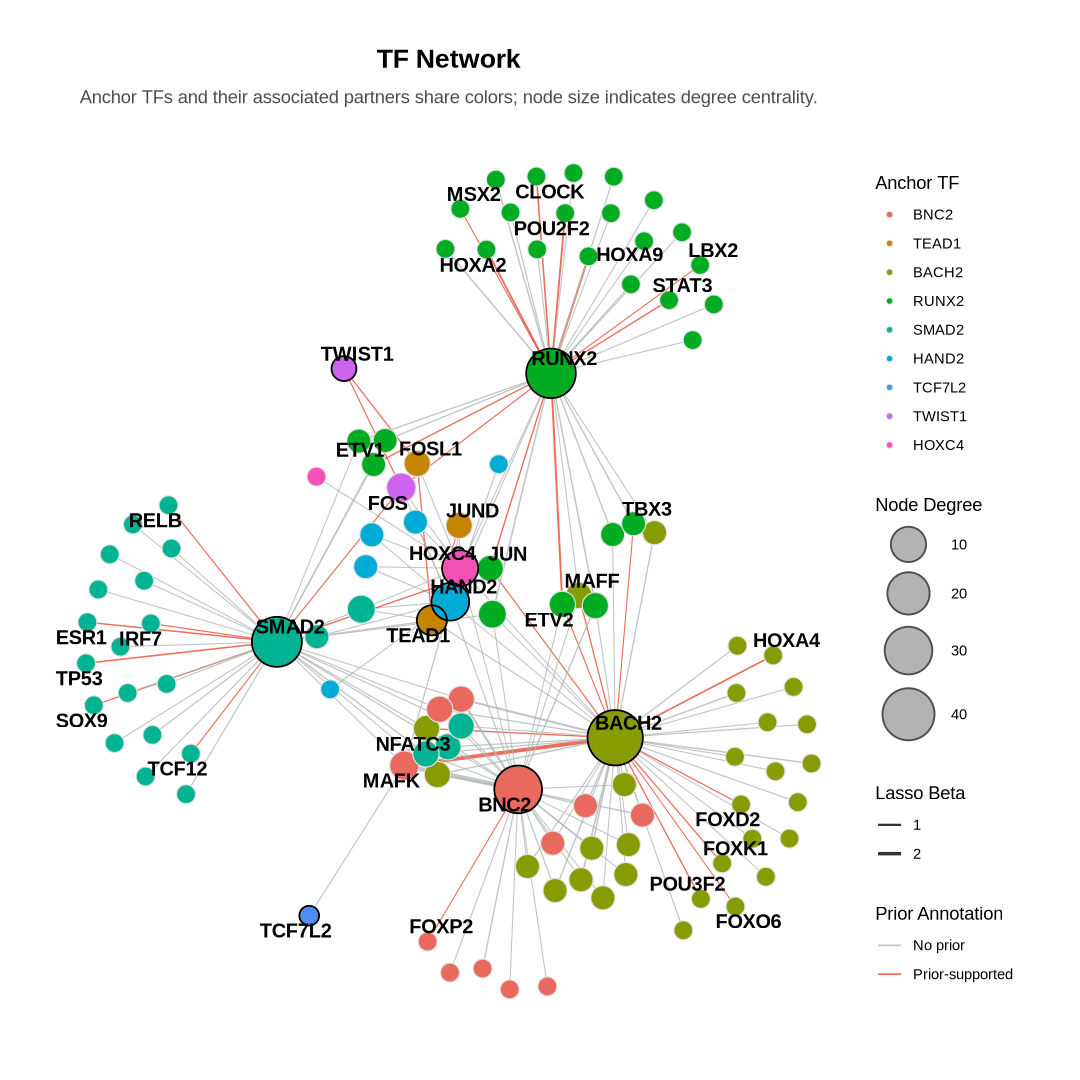

In [15]:
#TF-TF network
#plot_PROACT_network(pair_candidates = result) #all pairs
anchor_tfs <- c('BNC2','TEAD1','BACH2','RUNX2','SMAD2','HAND2','TCF7L2','TWIST1','HOXC4')
pair_candidates_sub <- result[result$TF1 %in% anchor_tfs|result$TF2 %in% anchor_tfs,]
options(repr.plot.width = 9, repr.plot.height = 9)
plot_PROACT_network(
    pair_candidates = pair_candidates_sub,
    anchor_tfs = anchor_tfs
)

## Analyze TF pair grammar

Dealing with 6503 features!



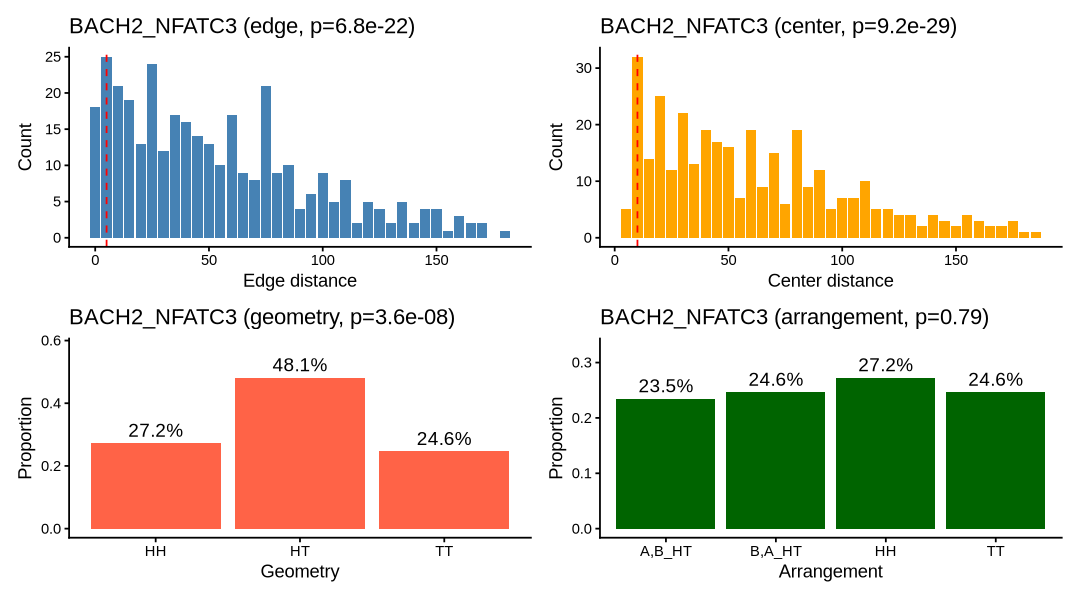

In [16]:
#TF grammar
pairs <- c('BACH2_NFATC3')
#1. detailed grammar features
pair_grammar <- find_grammar(object = pcancer, features = da_peaks,pairs = pairs,
                    strategy = 'best',assay = 'ATAC',region_length = 200,genome = BSgenome.Hsapiens.UCSC.hg38)
#pair_grammar$BACH2_NFATC3

#2. summary
res <- analyze_tf_grammar(result_list = pair_grammar)
#res

#3. plot
options(repr.plot.width = 9, repr.plot.height = 5)
plot_tf_grammar(res, pair = pairs)

### Session Information

In [17]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 9.7 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /home/handongmei/miniconda3/envs/R4.4/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] PROACT_0.1.0                      BSgenome.Hsapiens.UCSC.hg38_1.4.5
 [3] BSgenome_1.72.0                   rtracklayer_1.64.0               
 [5] BiocIO_1.14.0                     Biostrings_2.72.1      